In [2]:
from datasets import load_from_disk

dataset = load_from_disk("/Users/ssingodia/Desktop/Project-3/Task_5/content/cc12m_full")

print(dataset[0])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=800x572 at 0x17FE96530>, 'text': 'A letter S for squirrel stock illustration'}


In [57]:
full_dataset = dataset
print(len(full_dataset))


5001


In [58]:
image = dataset[0]["image"]
text = dataset[0]["text"]

print(text)
image.show()

A letter S for squirrel stock illustration


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [107]:
# from datasets import Dataset
# import random

# # Set seed for reproducibility (optional but recommended)
# seed = 42

# # Shuffle and select 20k samples
# train_dataset = full_dataset.shuffle(seed=seed).select(range(20000))

# print(train_dataset)




from datasets import Dataset

# Set seed for reproducibility
seed = 42

# Step 1: Shuffle full dataset
shuffled_dataset = full_dataset.shuffle(seed=seed)

# Step 2: Select splits
train_dataset = shuffled_dataset.select(range(3500))
val_dataset = shuffled_dataset.select(range(3500, 5001))

# Print info
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 3500
Validation size: 1501


In [108]:
from collections import defaultdict
import random

image_to_captions = defaultdict(list)

# Step 1: Build mapping
for item in val_dataset:
    image = item["image"]
    captions = item["text"]
    
    for caption in captions:
        image_to_captions[id(image)].append((image, caption))

print("Unique images:", len(image_to_captions))


# Step 2: Select 1 caption per image and store rest separately
unique_image_pairs = []
remaining_pairs = []

for image_id, captions_list in image_to_captions.items():
    
    # Randomly choose one caption for uniqueness
    chosen_pair = random.choice(captions_list)
    unique_image_pairs.append(chosen_pair)
    
    # Add the remaining captions directly (no comparison needed)
    for pair in captions_list:
        if pair != chosen_pair:
            remaining_pairs.append(pair)

print("Unique pairs:", len(unique_image_pairs))
print("Remaining pairs:", len(remaining_pairs))

Unique images: 1501
Unique pairs: 1501
Remaining pairs: 148124


In [109]:
final_val_pairs=unique_image_pairs 
random.shuffle(final_val_pairs)

print("Final validation dataset size:", len(final_val_pairs))

Final validation dataset size: 1501


In [110]:
import torch
import numpy as np
from tqdm import tqdm
from PIL import Image
import random
import os

from transformers import CLIPModel, CLIPProcessor
from datasets import load_dataset

In [111]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

state_dict = torch.load("/Users/ssingodia/Desktop/Project-3/Task_5/best_clip_model.pt", map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [112]:
# Extract images and captions
image_list = []
caption_list = []

for img, cap in final_val_pairs:
    image_list.append(img)
    caption_list.append(cap)

print("Images:", len(image_list))
print("Captions:", len(caption_list))

Images: 1501
Captions: 1501


In [113]:
def encode_images(images, batch_size=32):
    all_embeds = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]

        inputs = processor(images=batch, return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            feats = model.get_image_features(**inputs)
            feats = feats / feats.norm(dim=-1, keepdim=True)

        all_embeds.append(feats.cpu())

    return torch.cat(all_embeds)

In [114]:
def encode_texts(texts, batch_size=32):
    all_embeds = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = processor(text=batch, return_tensors="pt", padding=True, truncation=True).to(device)

        with torch.no_grad():
            feats = model.get_text_features(**inputs)
            feats = feats / feats.norm(dim=-1, keepdim=True)

        all_embeds.append(feats.cpu())

    return torch.cat(all_embeds)

In [115]:
print("Encoding images...")
image_embeds = encode_images(image_list)

print("Encoding captions...")
text_embeds = encode_texts(caption_list)

print("Shapes:", image_embeds.shape, text_embeds.shape)

Encoding images...
Encoding captions...
Shapes: torch.Size([1501, 512]) torch.Size([1501, 512])


In [116]:
tau = 0.07
similarity = (text_embeds @ image_embeds.T) / tau

In [117]:
def compute_recall(similarity, k_list=[1,5,10]):
    recalls = {k: 0 for k in k_list}
    n = similarity.shape[0]

    for i in range(n):
        sims = similarity[i]
        top_k = torch.topk(sims, max(k_list)).indices

        for k in k_list:
            if i in top_k[:k]:
                recalls[k] += 1

    for k in recalls:
        recalls[k] /= n

    return recalls

In [118]:
recall = compute_recall(similarity)

print("Conceptual_caption Results:")
print(f"R@1: {recall[1]:.4f}")
print(f"R@5: {recall[5]:.4f}")
print(f"R@10: {recall[10]:.4f}")

Conceptual_caption Results:
R@1: 0.0007
R@5: 0.0033
R@10: 0.0053


In [119]:
def mean_similarity(image_embeds, text_embeds):
    sims = []

    for i in range(len(text_embeds)):
        sim = (text_embeds[i] @ image_embeds[i]).item()
        sims.append(sim)

    return np.mean(sims)

In [120]:
mean_sim = mean_similarity(image_embeds, text_embeds)
print("Mean similarity:", mean_sim)

Mean similarity: 0.10106740103318523


In [121]:
def low_rank_failures(similarity, top_n=5):
    failures = []

    for i in range(len(similarity)):
        sims = similarity[i]

        ranking = torch.argsort(sims, descending=True)
        rank = (ranking == i).nonzero(as_tuple=True)[0].item()

        if rank > 50:
            failures.append((i, rank))

        if len(failures) >= top_n:
            break

    return failures

In [122]:
def wrong_top(similarity, top_n=5):
    failures = []

    for i in range(len(similarity)):
        sims = similarity[i]
        top1 = torch.argmax(sims).item()

        if top1 != i:
            failures.append((i, top1))

        if len(failures) >= top_n:
            break

    return failures

In [123]:
print("Low-rank failures:", low_rank_failures(similarity))
print("Wrong top predictions:", wrong_top(similarity))

Low-rank failures: [(1, 1208), (2, 293), (3, 138), (4, 1001), (5, 1114)]
Wrong top predictions: [(0, 468), (1, 865), (2, 865), (3, 1034), (4, 1034)]


In [124]:
flickr_results = {
    1: 0.54,   # replace with your actual values
    5: 0.79,
    10: 0.86
}

In [125]:
def compute_drop(flickr_results, ood_results):
    drop = {}
    
    for k in flickr_results:
        drop[k] = flickr_results[k] - ood_results[k]
    
    return drop

In [126]:
drop = compute_drop(flickr_results, recall)

print("Accuracy Drop:")
print(f"ΔR@1:  {drop[1]:.4f}")
print(f"ΔR@5:  {drop[5]:.4f}")
print(f"ΔR@10: {drop[10]:.4f}")

Accuracy Drop:
ΔR@1:  0.5393
ΔR@5:  0.7867
ΔR@10: 0.8547


In [130]:
# from datasets import Dataset

# # Set seed for reproducibility
# seed = 42

# # Step 1: Shuffle full dataset
# shuffled_dataset = full_dataset.shuffle(seed=seed)

# # Step 2: Select splits
# train_dataset = shuffled_dataset.select(range(5000))
# # val_dataset = shuffled_dataset.select(range(20000, 23000))

# # Print info

print("Training size:", len(train_dataset))

Training size: 3500


In [133]:
from collections import defaultdict
import random

train_image_to_captions = defaultdict(list)

# Step 1: Build mapping
for item in train_dataset:
    image = item["image"]
    captions = item["text"]
    
    for caption in captions:
        train_image_to_captions[id(image)].append((image, caption))

print("Unique images:", len(train_image_to_captions))


# Step 2: Select 1 caption per image and store rest separately
train_unique_image_pairs = []
train_remaining_pairs = []

for image_id, captions_list in train_image_to_captions.items():
    
    # Randomly choose one caption for uniqueness
    chosen_pair = random.choice(captions_list)
    train_unique_image_pairs.append(chosen_pair)
    
    # Add the remaining captions directly (no comparison needed)
    for pair in captions_list:
        if pair != chosen_pair:
            train_remaining_pairs.append(pair)

print("Unique pairs:", len(train_unique_image_pairs))
print("Remaining pairs:", len(train_remaining_pairs))

Unique images: 3500
Unique pairs: 3500
Remaining pairs: 338281


In [134]:
final_train_pairs=train_unique_image_pairs
# final_train_pairs=train_dataset 
random.shuffle(final_train_pairs)


print("Final training dataset size:", len(final_train_pairs))


Final training dataset size: 3500


In [135]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [136]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [137]:
import torch
import torch.nn as nn
import numpy as np

logit_scale = nn.Parameter(torch.tensor(np.log(1/0.07), dtype=torch.float32))
logit_scale = logit_scale.to(device)

In [138]:
clean_pairs = []

for img, cap in final_train_pairs:
# for img, cap in train_pairs:
    try:
        if img is None:
            continue
            
        # ensure PIL image RGB
        img = img.convert("RGB")
        
        # ensure caption string
        cap = str(cap)
        
        clean_pairs.append((img, cap))
        
    except:
        continue

len(clean_pairs)


3500

In [139]:
from torch.utils.data import Dataset

In [140]:
class FlickrDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
        
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        image, caption = self.pairs[idx]
        return image, caption


In [141]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def collate_fn(batch):
    images, captions = zip(*batch)
    
    inputs = processor(
        text=list(captions),
        images=list(images),
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    
    return inputs


In [142]:
from torch.utils.data import DataLoader

In [144]:
train_pairs = final_train_pairs

train_data = FlickrDataset(train_pairs)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

In [145]:
batch = next(iter(train_loader))

for key in batch:
    print(key, batch[key].shape)


input_ids torch.Size([32, 3])
attention_mask torch.Size([32, 3])
pixel_values torch.Size([32, 3, 224, 224])


In [146]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

batch = {k: v.to(device) for k, v in batch.items()}


In [147]:
import torch
from transformers import CLIPModel

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model = model.to(device)

model.train()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [148]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['input_ids', 'attention_mask', 'pixel_values'])


In [149]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-6)


from torch.optim import AdamW

logit_scale = logit_scale.detach().requires_grad_()
optimizer = AdamW(
    list(model.parameters()) + [logit_scale],
    lr=2e-6
)

# from torch.optim import AdamW

# # make sure logit_scale is a leaf parameter
# logit_scale = logit_scale.detach().requires_grad_()

# optimizer = AdamW([
    
#     # Vision encoder (image model) → smaller LR
#     {"params": model.vision_model.parameters(), "lr": 1e-6},
    
#     # Text encoder → higher LR
#     {"params": model.text_model.parameters(), "lr": 5e-6},
    
#     # Projection layers (important for alignment)
#     {"params": model.visual_projection.parameters(), "lr": 5e-6},
#     {"params": model.text_projection.parameters(), "lr": 5e-6},
    
#     # Learned temperature
#     {"params": [logit_scale], "lr": 5e-6}
# ])


In [150]:
epochs = 1

for epoch in range(epochs):
    
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch in train_loader:
        
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        
        image_embeds = torch.nn.functional.normalize(outputs.image_embeds, dim=1)
        text_embeds = torch.nn.functional.normalize(outputs.text_embeds, dim=1)
        
        similarity = logit_scale.exp() * (image_embeds @ text_embeds.T)
        
        labels = torch.arange(similarity.size(0)).to(device)
        
        loss_i = torch.nn.functional.cross_entropy(similarity, labels)
        loss_t = torch.nn.functional.cross_entropy(similarity.T, labels)
        loss = (loss_i + loss_t) / 2
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
           
    avg_train_loss = total_loss / num_batches
    
    # validation loss
    # avg_val_loss = compute_validation_loss(model, val_loader, logit_scale)
    # # avg_val_loss = val_loss / len(val_loader)
    
    # # validation recall
    # val_recall = compute_recall(model, val_loader)
    
    print(f"\nEpoch {epoch+1}")
    print("Average Train Loss:", avg_train_loss)
    # print("Average Validation Loss:", avg_val_loss)
    # print("Validation Recall@10:", val_recall)
    print("Temperature:", 1 / logit_scale.exp().item())

#     # ----- EARLY STOPPING LOGIC -----
#     if val_recall > best_val_recall:
#         best_val_recall = val_recall
#         patience_counter = 0
        
#         # Save best model weights
#         best_model_state = model.state_dict()
#         print("New best model saved.")
        
#     else:
#         patience_counter += 1
#         print(f"No improvement. Patience: {patience_counter}/{patience}")
        
#     if patience_counter >= patience:
#         print("\nEarly stopping triggered.")
#         break

# if best_model_state is not None:
#     model.load_state_dict(best_model_state)
#     print("Best model restored.")


Epoch 1
Average Train Loss: 3.4620120308615943
Temperature: 0.0700069781583377


In [151]:
len(final_val_pairs)

1501

In [152]:
val_data = FlickrDataset(final_val_pairs)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [153]:
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [154]:
all_image_embeds = []
all_text_embeds = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        
        image_embeds = torch.nn.functional.normalize(outputs.image_embeds, dim=1)
        text_embeds = torch.nn.functional.normalize(outputs.text_embeds, dim=1)
        
        all_image_embeds.append(image_embeds)
        all_text_embeds.append(text_embeds)

all_image_embeds = torch.cat(all_image_embeds)
all_text_embeds = torch.cat(all_text_embeds)

print(all_image_embeds.shape)
print(all_text_embeds.shape)

torch.Size([1501, 512])
torch.Size([1501, 512])


In [155]:
similarity = all_text_embeds @ all_image_embeds.T
temperature = 0.07
similarity = similarity / temperature

In [156]:
import numpy as np

similarity_np = similarity.cpu().numpy()

recall_at_1 = 0
recall_at_5 = 0
recall_at_10 = 0

for i in range(len(similarity_np)):
    
    # sort indices in descending similarity
    ranked_indices = np.argsort(-similarity_np[i])
    
    if i in ranked_indices[:1]:
        recall_at_1 += 1
        
    if i in ranked_indices[:5]:
        recall_at_5 += 1
        
    if i in ranked_indices[:10]:
        recall_at_10 += 1

N = len(similarity_np)

print("Recall@1:", recall_at_1 / N)
print("Recall@5:", recall_at_5 / N)
print("Recall@10:", recall_at_10 / N)

Recall@1: 0.0006662225183211193
Recall@5: 0.0033311125916055963
Recall@10: 0.0073284477015323115


In [ ]:
# Before fine-tuning (zero-shot)
before_results = {
    1: recall[1],
    5: recall[5],
    10: recall[10]
}

# After fine-tuning (adapted model)
after_results = {
    1: recall_at_1 / N,
    5: recall_at_5 / N,
    10: recall_at_10 / N
}

In [158]:
def compute_adaptation_gain(before, after):
    return {k: after[k] - before[k] for k in before}

In [159]:
gain = compute_adaptation_gain(before_results, after_results)

In [160]:
print("\n===== ADAPTATION GAIN =====")

for k in [1, 5, 10]:
    print(f"R@{k}: Before={before_results[k]:.4f} | After={after_results[k]:.4f} | Gain={gain[k]:+.4f}")


===== ADAPTATION GAIN =====
R@1: Before=0.0007 | After=0.0007 | Gain=+0.0000
R@5: Before=0.0033 | After=0.0033 | Gain=+0.0000
R@10: Before=0.0053 | After=0.0073 | Gain=+0.0020


In [161]:
!pip install faiss-cpu

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [162]:
import faiss
import numpy as np

In [163]:
image_embeddings_np = all_image_embeds.cpu().numpy()
text_embeddings_np = all_text_embeds.cpu().numpy()

In [164]:
dimension = image_embeddings_np.shape[1]

index = faiss.IndexFlatIP(dimension)

In [165]:
index.add(image_embeddings_np)

In [179]:
query_text = ["e"]

inputs = processor(text=query_text, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    query_embedding = model.get_text_features(**inputs)

query_embedding = torch.nn.functional.normalize(query_embedding, dim=1)
query_embedding = query_embedding.cpu().numpy()

In [180]:
k = 7 # top results

distances, indices = index.search(query_embedding, k)

print(indices)

[[1470  866 1358  123 1347 1265    0]]


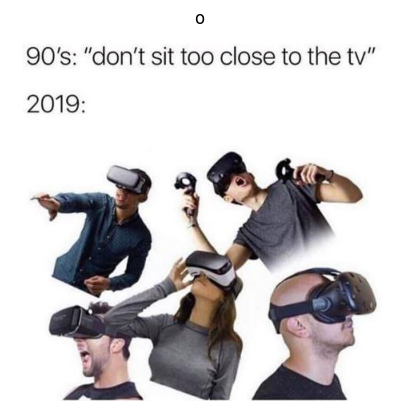

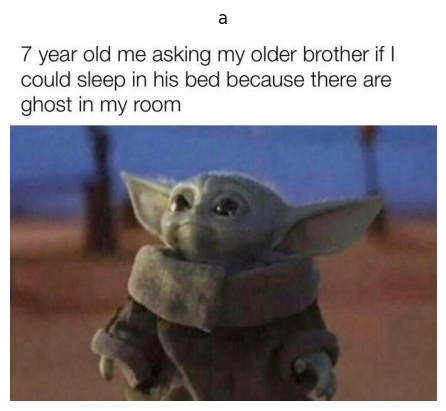

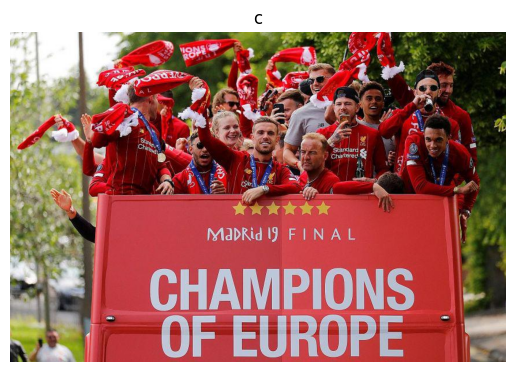

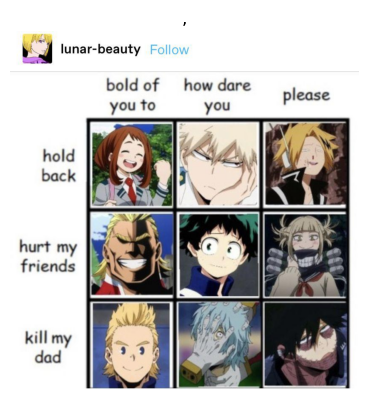

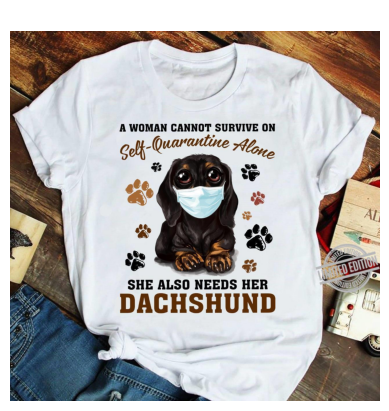

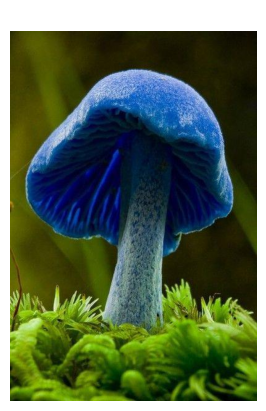

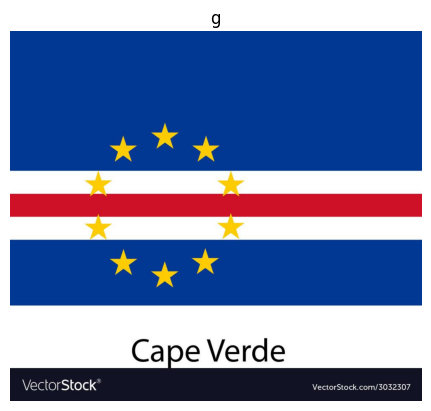

In [181]:
import matplotlib.pyplot as plt

for idx in indices[0]:
    image, caption = unique_image_pairs[idx]
    
    plt.imshow(image)
    plt.title(caption)
    plt.axis("off")
    plt.show()